In [41]:
import numpy as np
import matplotlib.pyplot as plt
# import cv2
import os
import tensorflow as tf
import keras as keras
from keras import utils
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.optimizers import Adam

In [43]:
dataset_path="Bone Break Classification"

In [44]:
train_data=utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    shuffle=True,
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=40,
)

vald_data=utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="validation",
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=40,
)


Found 1129 files belonging to 10 classes.
Using 1017 files for training.
Found 1129 files belonging to 10 classes.
Using 112 files for validation.


In [20]:
classes=train_data.class_names
classes

['Avulsion fracture',
 'Comminuted fracture',
 'Fracture Dislocation',
 'Greenstick fracture',
 'Hairline Fracture',
 'Impacted fracture',
 'Longitudinal fracture',
 'Oblique fracture',
 'Pathological fracture',
 'Spiral Fracture']

In [21]:
def normalize(image, label):
    image = image / 255.0
    return image, label

# Apply normalization to training and validation datasets
train_data = train_data.map(lambda img, lbl: normalize(img, lbl))
vald_data = vald_data.map(lambda img, lbl: normalize(img, lbl))
vald_data

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [22]:
def resize_image(image, label, target_size=(256, 256)):
    # Resize the image to the target size
    image = tf.image.resize(image, target_size)
    return image, label

# Apply resizing to make all images consistent in size
train_data = train_data.map(lambda img, lbl: resize_image(img, lbl))
vald_data = vald_data.map(lambda img, lbl: resize_image(img, lbl))

# Convert to lists and then to tensors
train_x, train_y = [], []

for image, label in train_data:
    train_x.append(image)
    train_y.append(label)

train_x = tf.concat(train_x, axis=0)
train_y = tf.concat(train_y, axis=0)


In [23]:
train_y

<tf.Tensor: shape=(1017,), dtype=int32, numpy=array([4, 2, 2, ..., 1, 1, 0])>

In [24]:
train_x

<tf.Tensor: shape=(1017, 256, 256, 3), dtype=float32, numpy=
array([[[[0.6443244 , 0.6443244 , 0.6443244 ],
         [0.6205499 , 0.6205499 , 0.6205499 ],
         [0.586314  , 0.586314  , 0.586314  ],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],

        [[0.654902  , 0.654902  , 0.654902  ],
         [0.6366461 , 0.6366461 , 0.6366461 ],
         [0.6071308 , 0.6071308 , 0.6071308 ],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],

        [[0.6516008 , 0.6516008 , 0.6516008 ],
         [0.63936514, 0.63936514, 0.63936514],
         [0.6139384 , 0.6139384 , 0.6139384 ],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],

        ...,

        [[0.6997233 , 0.6997233

In [25]:
val_x=[]
val_y=[]
for image,label in train_data:
   val_x.append(image)
   val_y.append(label)
val_x = tf.concat(val_x, axis=0)
val_y = tf.concat(val_y, axis=0)

In [26]:
#one hot encode
num_classes = 10
train_y = tf.keras.utils.to_categorical(train_y, num_classes=num_classes)
val_y = tf.keras.utils.to_categorical(val_y, num_classes=num_classes)

In [27]:
# Define the CNN model
model = Sequential()
model.add(Conv2D(60, (3, 3), activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(120, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(40, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy', metrics=['accuracy'])

In [28]:
model.fit(train_x, train_y, batch_size=10, epochs=10,
          validation_data=(val_x,val_y))

Epoch 1/10


102/102 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.1412 - loss: 3.4173 - val_accuracy: 0.2104 - val_loss: 2.2868
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.2070 - loss: 2.2636 - val_accuracy: 0.2704 - val_loss: 2.0276
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.3798 - loss: 1.8268 - val_accuracy: 0.6205 - val_loss: 1.2594
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.6299 - loss: 1.2126 - val_accuracy: 0.8289 - val_loss: 0.6598
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8128 - loss: 0.6667 - val_accuracy: 0.9341 - val_loss: 0.3416
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9217 - loss: 0.3696 - val_accuracy: 0.9754 - val_loss: 0.2172
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9668 - loss: 0.1821 - val_accuracy: 0.9538 - val_loss: 0.3477
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9693 - loss: 0.2405 - val_accuracy: 0.983

In [29]:
loss, accuracy = model.evaluate(val_x,val_y)
print('Test accuracy:', accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 362ms/step - accuracy: 0.9882 - loss: 0.0772
Test accuracy: 0.9921337366104126


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 396ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       0.98      1.00      0.99       127
           2       1.00      1.00      1.00       146
           3       0.99      1.00      1.00       112
           4       1.00      1.00      1.00       102
           5       1.00      0.95      0.97        76
           6       0.99      0.99      0.99        76
           7       1.00      0.99      0.99        75
           8       1.00      1.00      1.00       115
           9       0.95      0.97      0.96        79

    accuracy                           0.99      1017
   macro avg       0.99      0.99      0.99      1017
weighted avg       0.99      0.99      0.99      1017



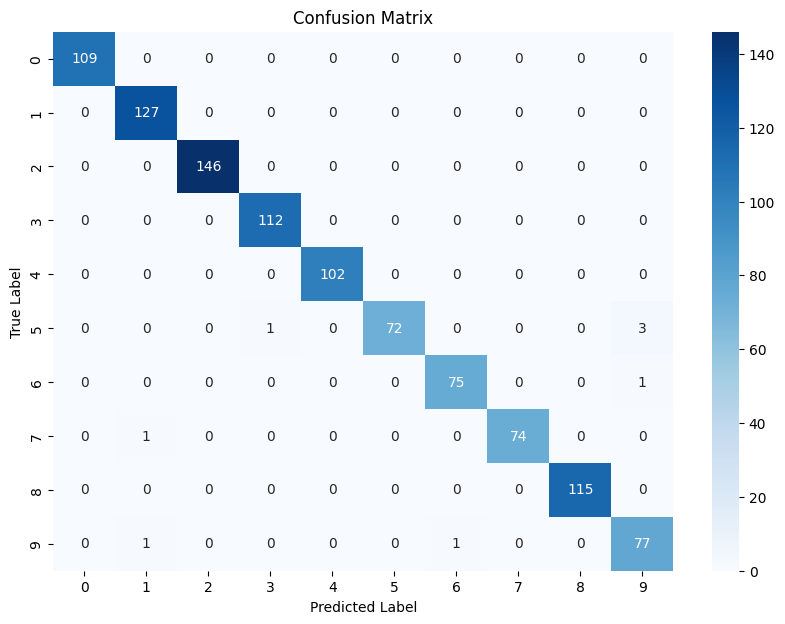

In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Make predictions on the validation set
val_predictions = model.predict(val_x)

# Step 2: Convert predicted probabilities to class labels
predicted_classes = np.argmax(val_predictions, axis=1)
true_classes = np.argmax(val_y, axis=1)

# Step 3: Generate the confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Step 4: Print the classification report
class_report = classification_report(true_classes, predicted_classes)
print('Classification Report:\n', class_report)

# Step 5: Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()


In [31]:
model.save("cnn.h5")

In [33]:
from keras.applications import MobileNet
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D
from keras.optimizers import Adam

# Load MobileNet model with pre-trained weights, excluding the top layer
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze the base model layers to prevent them from being updated during training
for layer in base_model.layers:
    layer.trainable = False

# Define the model
model = Sequential()
model.add(base_model)  # Add the MobileNet base model
model.add(GlobalAveragePooling2D())  # Add global average pooling
model.add(Dense(40, activation='relu'))  # Add a dense layer with 40 units
model.add(Dense(10, activation='softmax'))  # Output layer with 10 classes

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_x, train_y, batch_size=10, epochs=15, validation_data=(val_x, val_y))


C:\Users\0871\AppData\Local\Temp\ipykernel_13000\2877406463.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(256, 256, 3))


Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 56s 524ms/step - accuracy: 0.1826 - loss: 2.3608 - val_accuracy: 0.2429 - val_loss: 2.0927
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 47s 459ms/step - accuracy: 0.2576 - loss: 2.0863 - val_accuracy: 0.3825 - val_loss: 1.8802
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 502ms/step - accuracy: 0.3598 - loss: 1.8576 - val_accuracy: 0.4326 - val_loss: 1.7111
Epoch 4/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 493ms/step - accuracy: 0.4397 - loss: 1.6839 - val_accuracy: 0.4680 - val_loss: 1.5827
Epoch 5/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 48s 468ms/step - accuracy: 0.4877 - loss: 1.5399 - val_accuracy: 0.5998 - val_loss: 1.3249
Epoch 6/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 46s 455ms/step - accuracy: 0.5466 - loss: 1.3778 - val_accuracy: 0.6441 - val_loss: 1.1785
Epoch 7/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 502ms/step - accuracy: 0.6417 - loss: 1.1951 - val_accuracy: 0.6912 - val_loss: 1.0668
Epoch 8/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 48s 477ms/step - accuracy: 0.6615 - loss: 1

In [34]:
loss, accuracy = model.evaluate(val_x,val_y)
print('Test accuracy:', accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 829ms/step - accuracy: 0.9226 - loss: 0.4152
Test accuracy: 0.9154375791549683


32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 861ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.95      0.88       109
           1       0.95      0.83      0.89       127
           2       0.90      0.97      0.94       146
           3       0.96      0.98      0.97       112
           4       1.00      0.90      0.95       102
           5       0.90      0.87      0.89        76
           6       0.96      0.91      0.93        76
           7       0.96      0.71      0.82        75
           8       0.89      0.99      0.94       115
           9       0.87      0.95      0.91        79

    accuracy                           0.92      1017
   macro avg       0.92      0.91      0.91      1017
weighted avg       0.92      0.92      0.91      1017



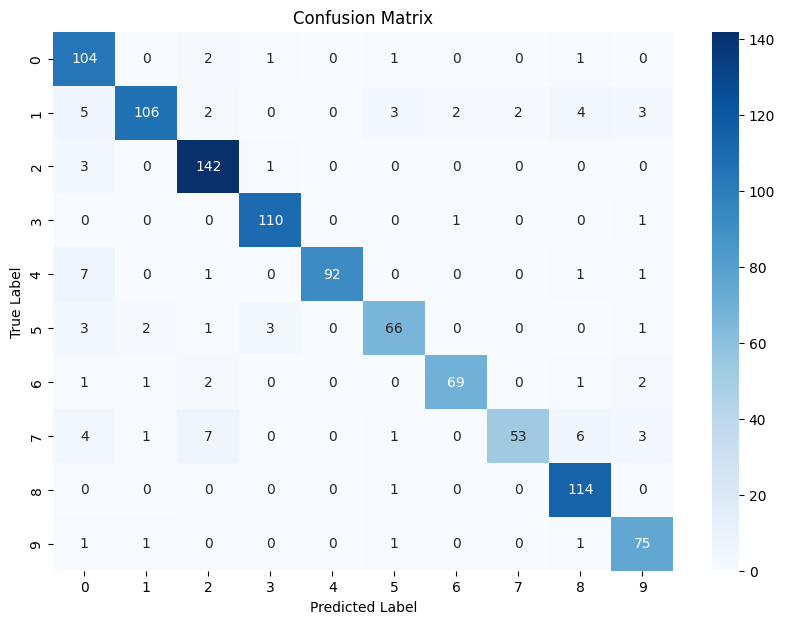

In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Make predictions on the validation set
val_predictions = model.predict(val_x)

# Step 2: Convert predicted probabilities to class labels
predicted_classes = np.argmax(val_predictions, axis=1)
true_classes = np.argmax(val_y, axis=1)

# Step 3: Generate the confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Step 4: Print the classification report
class_report = classification_report(true_classes, predicted_classes)
print('Classification Report:\n', class_report)

# Step 5: Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()


In [37]:
model.save("mobilenet.h5")

C:\Users\0871\AppData\Local\Temp\ipykernel_13000\3312257057.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(256, 256, 3))


32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 822ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 805ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       127
           2       1.00      1.00      1.00       146
           3       1.00      1.00      1.00       112
           4       1.00      1.00      1.00       102
           5       1.00      1.00      1.00        76
           6       1.00      1.00      1.00        76
           7       1.00      1.00      1.00        75
           8       1.00      1.00      1.00       115
           9       1.00      1.00      1.00        79

    accuracy                           1.00      1017
   macro avg       1.00      1.00      1.00      1017
weighted avg       1.00      1.00      1.00      1017



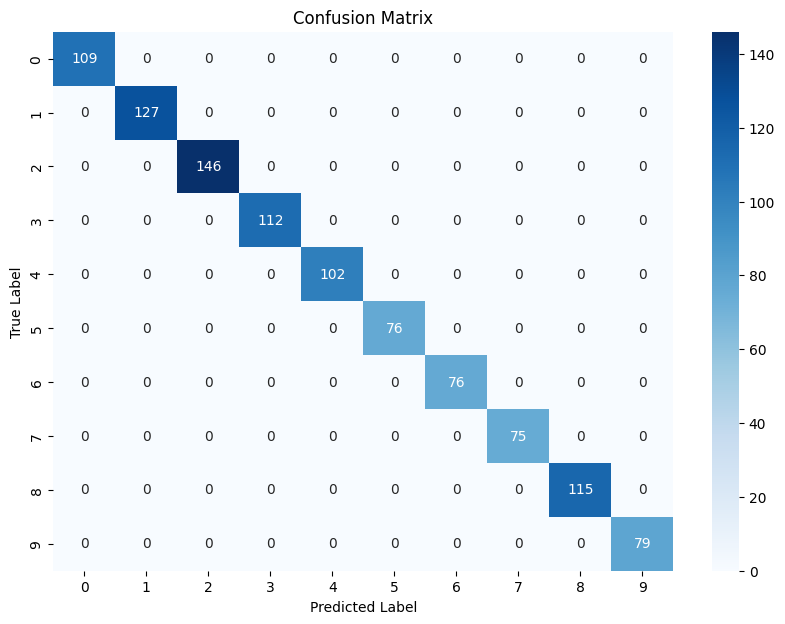

In [38]:
import numpy as np
from keras.applications import MobileNet
from keras.models import Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load MobileNet without the top layer
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_model.trainable = False  # Freeze the base model

# Step 2: Create a new model to extract features
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Step 3: Extract features from training and validation data
train_features = feature_extractor.predict(train_x)
val_features = feature_extractor.predict(val_x)

# Reshape features for the Random Forest classifier
train_features = train_features.reshape(train_features.shape[0], -1)
val_features = val_features.reshape(val_features.shape[0], -1)

# Step 4: Train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(train_features, np.argmax(train_y, axis=1))

# Step 5: Evaluate the Random Forest model on the validation set
val_predictions = rf_model.predict(val_features)

# Step 6: Generate the confusion matrix
conf_matrix = confusion_matrix(np.argmax(val_y, axis=1), val_predictions)

# Step 7: Print the classification report
class_report = classification_report(np.argmax(val_y, axis=1), val_predictions)
print('Classification Report:\n', class_report)

# Step 8: Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()


In [40]:
import joblib
# Step 1: Save the MobileNet feature extractor
feature_extractor.save('mobilenet_feature_extractor.h5')

# Step 2: Save the Random Forest classifier using joblib
joblib.dump(rf_model, 'random_forest_classifier.pkl')

print("Models saved successfully.")

Models saved successfully.


In [56]:
import numpy as np
import cv2  # OpenCV for image loading and processing
from keras.models import load_model
import joblib
import tensorflow as tf

# Step 1: Load the models
feature_extractor = load_model('mobilenet_feature_extractor.h5')
rf_model = joblib.load('random_forest_classifier.pkl')

# Step 2: Preprocess the new image
def preprocess_image(image_path):
    # Load the image
    img = cv2.imread(image_path)
    
    # Resize the image to (256, 256)
    img = cv2.resize(img, (256, 256))
    
    # Normalize the image
    img = img / 255.0
    
    # Expand dimensions to fit the model input shape
    img = np.expand_dims(img, axis=0)  # Shape: (1, 256, 256, 3)
    
    return img

# Provide the path to your new image
image_path = r'Bone Break Classification\Impacted fracture\Train\41598_2020_64479_Fig1_HTML_png.rf.56031035bb06aff4ac684238f3d05539.jpg'  # Change this to your image path
new_image = preprocess_image(image_path)

# Step 3: Extract features using MobileNet
features = feature_extractor.predict(new_image)

# Reshape features for the Random Forest classifier
features = features.reshape(features.shape[0], -1)

# Step 4: Predict using the Random Forest classifier
prediction_index = rf_model.predict(features)[0]

# Class names
class_names = [
    'Avulsion fracture',
    'Comminuted fracture',
    'Fracture Dislocation',
    'Greenstick fracture',
    'Hairline Fracture',
    'Impacted fracture',
    'Longitudinal fracture',
    'Oblique fracture',
    'Pathological fracture',
    'Spiral Fracture'
]

# Output the predicted class name
predicted_class = class_names[prediction_index]
print(f'Predicted Class: {predicted_class}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
Predicted Class: Impacted fracture
